In [32]:
# Network analysis
import networkx as nx

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# I/O and utilities
import pickle
import json
import os
import time
import sys

# Optional (se serve per analisi avanzate)
import scipy
import random

# Plots requested: exclude singletons, square figures, remove top/right spines, labels in English
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [33]:
graph_path = "./graph_construction/outputs_graph/citation_graph_acyclic_post2015.gpickle"

## Connected Components Analysis

This section summarizes connected components (CCs) in the internal UniPi publication network to highlight clusters of research activity and isolated groups. External citations are excluded to focus on internal collaboration patterns.

**Note:** the constructed graph also excludes incoming citations from external papers to UniPi (edges from outside → UniPi). This omission introduces an intrinsic bias: in-degree and any metric that depends on incoming links will be underestimated relative to the true global citation network. Interpret comparisons with global graphs accordingly.

1. Issues with degree and centrality metrics: including external nodes inflates in/out-degree and biases measures like PageRank and betweenness, misrepresenting internal importance.
2. Bias from external data: external citations come from diverse fields and practices and can introduce noise that distorts density, centrality, and community-detection results.
3. Distortion of CCs: external nodes may create links that merge components which are otherwise separate internally, producing misleading component sizes.
4. Computational efficiency: the global graph is very large, so restricting to UniPi enables tractable computation of detailed metrics and community detection.
5. Focus on internal insights: analyzing only UniPi highlights collaboration patterns and sub-communities relevant to the institution without external noise.

Conclusion: restricting the analysis to internal UniPi nodes yields more reliable and interpretable results for density, centrality, and component structure, but remember the intrinsic bias from excluding incoming external citations when comparing to global data.

### General Strategy (updated)

We use a three‑level approach to analyse connected components (CCs):

1. Size classification  
   - Isolated: 1 node  
   - Tiny: 2–19 nodes  
   - Small: 20–99 nodes  
   - Medium: 100–999 nodes  
   - Large / LCC: 1000+ nodes

2. Category-specific strategy (trade off insight vs cost)  
   - LCC (Large): full analysis. Compute PageRank on the directed graph. For topological metrics used for cross‑CC comparison (betweenness, clustering, density, diameter / avg shortest path) compute them on the undirected projection (.to_undirected()). Use exact betweenness only if LCC size is small (example threshold: n <= 70k); otherwise compute sampled betweenness (k = min(1000, n)). Compute diameter exactly only for components under a configurable path_size_threshold; otherwise approximate via sampling.  
   - Medium: per‑component analysis. Compute betweenness, clustering and density on .to_undirected(). Compute PageRank on the directed subgraph if direction matters. Use exact metrics only when component size permits; otherwise use sampling for betweenness/diameter.  
   - Small: aggregated analysis (means / distributions) over consistent projections (e.g., densities and clustering on undirected projections, avg PageRank on directed).  
   - Tiny & Isolated: lightweight characterization (density, edge count, detect star/tree patterns) and print a few example node IDs for manual inspection.

3. Detailed analysis and reproducibility notes  
   - Metrics that should be computed on the directed graph: PageRank, in_degree/out_degree and any direction‑sensitive measures.  
   - Metrics that should be computed on the undirected projection for fair comparison across CCs: betweenness centrality, average_clustering, density, diameter / average shortest path (or on SCCs when appropriate). Always document which projection was used.  
   - Sampling defaults: betweenness sample k = min(1000, n) when n is large; diameter sampling: sample sampling_k sources and sampling_iters repeats (defaults: sampling_k=1000, sampling_iters=100). Make thresholds configurable.  
   - I/O robustness: ensure external nodes removal is defensive (d.get('external', False)) and log the number of removed nodes.  
   - Fixes to code to apply: remove stray/mismatched parentheses in betweenness branch, replace invalid legend arguments / misplaced bbox_transform, and avoid duplicated DataFrame constructions.  
   - Expected outputs: CC counts by category, total nodes per category, avg/median CC size, LCC and top‑K medium CC summaries, PR vs betweenness plots, rank‑size and cumulative coverage plots, and density vs size comparisons.

This markdown is aligned with the code corrections to be applied: it standardises .to_undirected() for topological comparisons, specifies sampling/threshold behaviour, and asks for defensive logging and minor syntax fixes.

In [34]:
def create_graphs(g):
    """
    Load pickled graph and return four graphs:
       - total_undirected
       - total_directed
       - internal_undirected (nodes with external==False removed)
       - internal_directed
    """
    with open(g, 'rb') as f:
        G = pickle.load(f)

    total_undirected = G.to_undirected()
    total_directed = G.copy()

    def remove_external_nodes(graph, directed: bool):
        g = graph.copy() if directed else graph.to_undirected()
        to_remove = [n for n, d in g.nodes(data=True) if d.get('external', False)]
        if to_remove:
            g.remove_nodes_from(to_remove)
        return g

    internal_undirected = remove_external_nodes(G, directed=False)
    internal_directed = remove_external_nodes(G, directed=True)

    return {
        "total_undirected": total_undirected,
        "total_directed": total_directed,
        "internal_undirected": internal_undirected,
        "internal_directed": internal_directed,
    }

In [35]:

def print_graph_stats(graphs: dict):
    """Print basic stats for each graph in the dict."""
    for name, g in graphs.items():
        kind = "directed" if g.is_directed() else "undirected"
        print(f"\n{name}:")
        print(f"  nodes: {g.number_of_nodes():,}")
        print(f"  edges: {g.number_of_edges():,}")
        print(f"  type: {kind}")


### Level 1: CC Size Classification
- Identify all CCs and count the number of nodes in each.  
- Categorize CCs based on size:  
  - **Isolated (1 node)**  
  - **Tiny (2-19 nodes)**  
  - **Small (20-99 nodes)**  
  - **Medium (100-999 nodes)**  
  - **Large (LCC, 1000+ nodes)**  

**Objective:**  
Understand the overall structure of the network, identify major clusters, and determine the relative importance of each component.

**Expected Outputs:**  
- Number of CCs per category.  
- Total nodes per category.  
- Average and median CC size.

In [36]:
def load_internal_directed(g):
    """Load pickled graph and return only the internal directed graph
    (nodes with node['external']==True are removed)."""
    with open(g, 'rb') as f:
        G = pickle.load(f)

    Gd = G.copy()  # keep directed structure
    to_remove = [n for n, d in Gd.nodes(data=True) if d.get('external', False)]
    if to_remove:
        Gd.remove_nodes_from(to_remove)
    return Gd

In [37]:
G = load_internal_directed(graph_path)
# Level 1: CC Size Classification (robust summary + examples)
total_nodes_in_graph = G.number_of_nodes()
ccs = list(nx.weakly_connected_components(G))

if not ccs:
    print("No connected components found.", flush=True)
else:
    cc_sizes = np.array([len(cc) for cc in ccs])

    # categorize
    isolated =  [cc for cc in ccs if len(cc) == 1]
    tiny =      [cc for cc in ccs if 1 < len(cc) <= 10]
    small =     [cc for cc in ccs if 10 < len(cc) <= 100]
    medium =    [cc for cc in ccs if 100 < len(cc) <= 1000]
    large =     [cc for cc in ccs if len(cc) > 1000]

    categories = [
        ("Isolated (1)", isolated),
        ("Tiny (2-10)", tiny),
        ("Small (11-100)", small),
        ("Medium (101-1000)", medium),
        ("Large (1001)", large),
    ]

    print(f"Total nodes in graph: {total_nodes_in_graph:,}", flush=True)
    print(f"Total CCs: {len(ccs):,}\n", flush=True)

    for name, comp_list in categories:
        count = len(comp_list)
        nodes_in_cat = sum(len(c) for c in comp_list)
        pct_nodes = (nodes_in_cat / total_nodes_in_graph * 100) if total_nodes_in_graph > 0 else 0.0
        print(f"{name}: {count} components, {nodes_in_cat:,} nodes ({pct_nodes:.1f}% of graph)", flush=True)

    # overall CC-size stats
    print("\nOverall CC size statistics:", flush=True)
    print(f"  mean = {cc_sizes.mean():.2f}, median = {np.median(cc_sizes):.1f}, max = {int(cc_sizes.max())}", flush=True)

    # LCC
    lcc = max(ccs, key=len)
    lcc_size = len(lcc)
    print(f"\nLCC size: {lcc_size:,} nodes ({lcc_size/total_nodes_in_graph*100:.1f}% of graph)\n", flush=True)

Total nodes in graph: 57,618
Total CCs: 16,275

Isolated (1): 14154 components, 14,154 nodes (24.6% of graph)
Tiny (2-10): 2011 components, 5,817 nodes (10.1% of graph)
Small (11-100): 106 components, 2,119 nodes (3.7% of graph)
Medium (101-1000): 3 components, 765 nodes (1.3% of graph)
Large (1001): 1 components, 34,763 nodes (60.3% of graph)

Overall CC size statistics:
  mean = 3.54, median = 1.0, max = 34763

LCC size: 34,763 nodes (60.3% of graph)



In [38]:
# ...existing code...
def tidy_square(ax, make_square=True, grid=True):
    """
    Remove top/right spines, optionally force square aspect and draw grid.
    If grid=True the function will add major (dashed) and minor (dotted) grid lines.
    It handles linear and log scales (uses LogLocator+LogFormatter on log axes).
    """
    try:
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    except Exception:
        pass

    if make_square:
        try:
            ax.set_aspect('equal', adjustable='box')
        except Exception:
            pass

    if not grid:
        return

    try:
        from matplotlib.ticker import LogLocator, LogFormatterSciNotation
        # grid styles
        major_kw = dict(ls='--', linewidth=0.6, alpha=0.8)
        minor_kw = dict(ls=':', linewidth=0.4, alpha=0.6)

        # X axis
        try:
            xscale = ax.get_xscale()
            if xscale == 'log':
                ax.xaxis.set_major_locator(LogLocator(base=10.0))
                ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto"))
                ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
            else:
                ax.minorticks_on()
        except Exception:
            pass

        # Y axis
        try:
            yscale = ax.get_yscale()
            if yscale == 'log':
                ax.yaxis.set_major_locator(LogLocator(base=10.0))
                ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto"))
                ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
            else:
                ax.minorticks_on()
        except Exception:
            pass

        # draw grids (major + minor)
        try:
            ax.grid(which='major', **major_kw)
            ax.grid(which='minor', **minor_kw)
        except Exception:
            try:
                ax.grid(True)
            except Exception:
                pass
    except Exception:
        # fallback: simple grid on major ticks
        try:
            ax.grid(True, ls='--', alpha=0.6)
        except Exception:
            pass
# ...existing code...

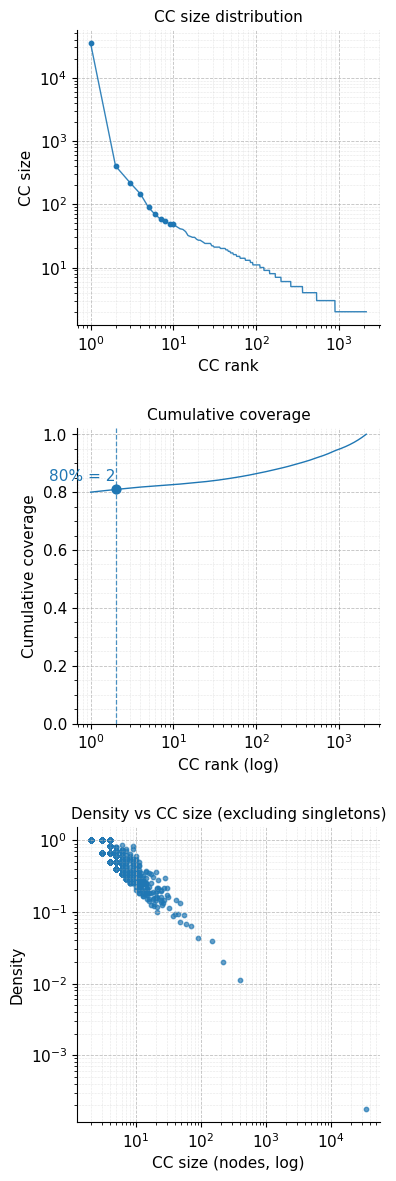

In [39]:
# styling
FONTSIZE_TITLE = 11
FONTSIZE_LABEL = 11
FONTSIZE_TICKS = 11

# Build list of components excluding singletons (robust)
if 'ccs' in globals() and ccs:
    ccs_excl = [cc for cc in ccs if len(cc) > 1]
elif 'ccs_all' in globals() and ccs_all:
    ccs_excl = [cc for cc in ccs_all if len(cc) > 1]
else:
    # fallback: try connected components from G if available
    try:
        if G.is_directed():
            all_ccs = list(nx.weakly_connected_components(G))
        else:
            all_ccs = list(nx.connected_components(G))
        ccs_excl = [cc for cc in all_ccs if len(cc) > 1]
    except Exception:
        ccs_excl = []

# sort components by size descending and compute sizes/ranks/cumulative coverage
if ccs_excl:
    comps_sorted = sorted(ccs_excl, key=len, reverse=True)
    sizes_excl = np.array([len(cc) for cc in comps_sorted], dtype=int)
    ranks_excl = np.arange(1, len(sizes_excl) + 1)
    total_excl = float(sizes_excl.sum()) if sizes_excl.size > 0 else 1.0
    cum_excl = np.cumsum(sizes_excl) / total_excl
    # densities aligned with sorted components
    densities = np.array([nx.density(G.subgraph(cc).to_undirected()) for cc in comps_sorted], dtype=float)
else:
    sizes_excl = np.array([], dtype=int)
    ranks_excl = np.array([], dtype=int)
    cum_excl = np.array([], dtype=float)
    densities = np.array([], dtype=float)

# If no components >1 node, print and skip plotting
if sizes_excl.size == 0:
    print("No components with >1 node to plot.", flush=True)
else:
    # Prepare figure with 3 vertical subplots
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(4, 12), constrained_layout=False)

    # Top: Rank-size (log-log)
    ax = axes[0]
    ax.plot(ranks_excl, sizes_excl, linestyle='-', linewidth=1.0, color='C0', alpha=0.9)
    n_mark = min(10, len(ranks_excl))
    ax.scatter(ranks_excl[:n_mark], sizes_excl[:n_mark], s=10, color='C0', zorder=5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("CC rank", fontsize=FONTSIZE_LABEL)
    ax.set_ylabel("CC size", fontsize=FONTSIZE_LABEL)
    ax.set_title("CC size distribution", fontsize=FONTSIZE_TITLE)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICKS)
    tidy_square(ax, make_square=False)

    # Middle: Cumulative coverage (only excluding singletons) with 80% marker
    ax = axes[1]
    ax.plot(ranks_excl, cum_excl, linestyle='-', marker=None, color='C0', linewidth=1)
    thr = 0.80
    k_idx = np.searchsorted(cum_excl, thr)
    if k_idx < len(ranks_excl):
        pct = int(round(thr * 100))
        ax.scatter([ranks_excl[k_idx]], [cum_excl[k_idx]], s=40, color='C0', zorder=6)
        ax.axvline(ranks_excl[k_idx], color='C0', ls='--', lw=0.9, alpha=0.8)
        ax.text(ranks_excl[k_idx], 0.88, f"{pct}% = {ranks_excl[k_idx]}", color='C0', fontsize=FONTSIZE_LABEL, va="top", ha="right")
    ax.set_xscale("log")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("CC rank (log)", fontsize=FONTSIZE_LABEL)
    ax.set_ylabel("Cumulative coverage", fontsize=FONTSIZE_LABEL)
    ax.set_title("Cumulative coverage", fontsize=FONTSIZE_TITLE)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICKS)
    tidy_square(ax, make_square=False)

    # Bottom: Density vs Size (excluding singletons)
    ax = axes[2]
    ax.scatter(sizes_excl, densities, s=10, alpha=0.7, color="C0")
    ax.set_xscale("log")
    if np.all(np.isfinite(densities)) and np.all(densities > 0):
        ax.set_yscale("log")
    ax.set_xlabel("CC size (nodes, log)", fontsize=FONTSIZE_LABEL)
    ax.set_ylabel("Density", fontsize=FONTSIZE_LABEL)
    ax.set_title("Density vs CC size (excluding singletons)", fontsize=FONTSIZE_TITLE)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICKS)
    tidy_square(ax, make_square=False)

    # adjust layout: more space between plots and room for x-axis labels
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, bottom=0.05, top=0.96)
    plt.show()
# ...existing code...

### Focused CC strategy — paper‑ready (4 large CCs)

Context
- Graph contains 4 CCs with >1000 nodes.
- Exclude singleton nodes from detailed reporting.

Key rules (state projection in outputs)
- CC detection: nx.weakly_connected_components (directed graph).
- Directional metrics (PageRank, in/out degree): compute on directed CC subgraph.
- Topological metrics (betweenness, clustering, density, diameter / avg shortest path): compute on undirected projection (sub.to_undirected()).
- Log whether metrics were computed exactly or approximately (sampling parameters below).

Concise workflow
1. Select top_k = 4 largest CCs for full profiling. Exclude singletons from plots.
2. For each large CC produce a compact panel:
   - PR vs Betweenness scatter (PR on directed, BW on undirected). Normalize PR per CC; annotate if BW sampled.
   - Inset: in‑degree distribution (log bins).
   - Short table: top‑5 nodes by PageRank and by Betweenness (ID + brief metadata).
3. Compact snapshot of remaining CCs:
   - Rank‑size (log‑log) and Density vs Size (log x). Small summary table: counts by category and basic stats.
4. Minimal random baselines (optional): n_sims_random_models = 20, report only z/p for density and clustering for the 4 CCs.

Defaults (tunable)
- top_k = 4
- exclude_singletons = True
- betweenness_exact_threshold = 5000  # full BW only if n ≤ threshold
- betweenness_sampling_k = 500
- path_size_threshold = 20000
- sampling_iters (diameter) = 50
- n_sims_random_models = 20

Presentation
- Produce one multi‑panel figure: 4 CC panels + one snapshot panel for others. Export as vector PDF / high‑res PNG.
- Include a one‑line methods note stating projections and sampling choices; flag external‑node exclusion bias on in‑degree/PageRank.

Implementation notes
- Expose thresholds as function args and print them at run start.
- Use safe normalization to avoid divide‑by‑zero in plots.
- Avoid exhaustive per‑singleton analysis; report aggregated singleton counts only.

Saved: ./cc_rank_density.png


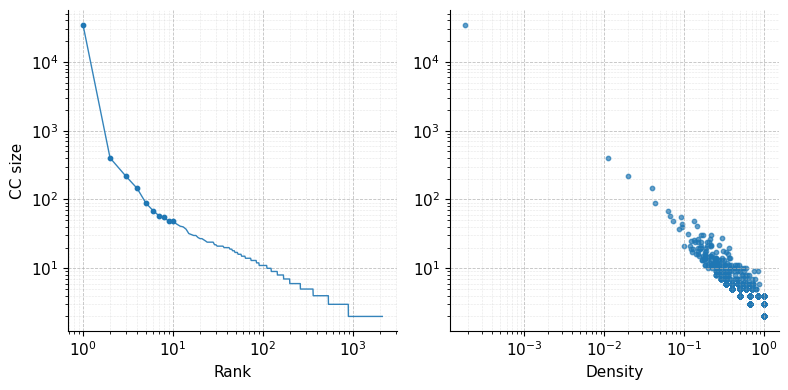

In [40]:
# ...existing code...
if sizes_excl.size == 0:
    print("No components with >1 node to plot.", flush=True)
else:
    # --- Figures: Rank-size (left) + Density vs Size (right) affiancate ---
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Left: Rank-size (log-log)
    ax1.plot(ranks_excl, sizes_excl, linestyle='-', linewidth=1.0, color='C0', alpha=0.9)
    n_mark = min(10, len(ranks_excl))
    ax1.scatter(ranks_excl[:n_mark], sizes_excl[:n_mark], s=10, color='C0', zorder=5)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Rank", fontsize=FONTSIZE_LABEL)
    ax1.set_ylabel("CC size", fontsize=FONTSIZE_LABEL)
    ax1.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICKS)
    tidy_square(ax1, make_square=False)

    # Right: Density vs Size (excluding singletons)
# ...existing code...
    # Right: Density vs Size (excluding singletons) -- INVERTED: density on x, size on y
    ax2.scatter(densities, sizes_excl, s=10, alpha=0.7, color="C0")
    # density è ora asse x: usare scala log solo se tutte le density sono finite e positive
    if np.all(np.isfinite(densities)) and np.all(densities > 0):
        ax2.set_xscale("log")
    # size è ora asse y: manteniamo log per le dimensioni dei CC
    ax2.set_yscale("log")
    # rendere i titoli degli assi esemplificativi (in italiano)
    ax2.set_xlabel("Density", fontsize=FONTSIZE_LABEL)
    ax2.set_ylabel("")  # rimosso: coincide concettualmente con l'altro grafico
    ax2.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICKS)
    tidy_square(ax2, make_square=False)
# ...existing code...

    plt.tight_layout()
    try:
        fig.savefig("./cc_rank_density.png", dpi=300)
        print("Saved: ./cc_rank_density.png", flush=True)
    except Exception:
        pass
    plt.show()
# ...existing code...

In [41]:
# ...existing code...
def compute_focused_cc_metrics(
    G,
    exclude_singletons=True,
    betweenness_exact_threshold=5000,
    betweenness_sampling_k=500,
    path_size_threshold=20000,
    sampling_iters=50,
    rng_seed=12345,
):
    """
    Compute and return metrics for the largest component (LCC) without plotting.
    Returns a dict with: sub_dir, sub_und, nodes, pr, pr_arr, indeg_map, indeg_arr,
    bw, bw_arr, stats, sampled (whether betweenness was sampled).
    """
    import time

    # select LCC
    if G.is_directed():
        comps = list(nx.weakly_connected_components(G))
    else:
        comps = list(nx.connected_components(G))
    if exclude_singletons:
        comps = [c for c in comps if len(c) > 1]
    if not comps:
        raise ValueError("No components to analyze")

    lcc_nodes = max(comps, key=len)
    sub_dir = G.subgraph(lcc_nodes).copy()
    sub_und = sub_dir.to_undirected()
    nodes = list(sub_und.nodes())
    n_sub = len(nodes)
    m_sub = sub_und.number_of_edges()

    # PageRank (directed) and normalization
    t0 = time.time()
    pr = nx.pagerank(sub_dir)
    t_pr = time.time() - t0
    pr_vals = np.array([pr.get(n, 0.0) for n in nodes], dtype=float)
    pr_min, pr_max = (pr_vals.min() if pr_vals.size else 0.0, pr_vals.max() if pr_vals.size else 0.0)
    denom = (pr_max - pr_min) if (pr_max - pr_min) > 0 else 1e-12
    pr_arr = (pr_vals - pr_min) / denom

    # in-degree aligned
    indeg_map = dict(sub_dir.in_degree())
    indeg_arr = np.array([int(indeg_map.get(n, 0)) for n in nodes], dtype=int)

    # betweenness (undirected): exact or sampled
    sampled = False
    t0 = time.time()
    if n_sub <= betweenness_exact_threshold:
        bw = nx.betweenness_centrality(sub_und, normalized=True)
        sampled = False
    else:
        k = min(betweenness_sampling_k, n_sub)
        bw = nx.betweenness_centrality(sub_und, k=int(k), normalized=True, seed=int(rng_seed))
        sampled = True
    bw_arr = np.array([bw.get(n, np.nan) for n in nodes], dtype=float)

    # basic metrics
    density = nx.density(sub_und)
    try:
        avg_clust = nx.average_clustering(sub_und)
    except Exception:
        avg_clust = np.nan

    # diameter (approx if large)
    diam = np.nan
    diam_method = "skipped"
    if n_sub > 1:
        if n_sub <= path_size_threshold:
            try:
                diam = nx.diameter(sub_und)
                diam_method = "exact"
            except Exception:
                diam = np.nan
                diam_method = "failed"
        else:
            rng = np.random.default_rng(rng_seed)
            sample_k = min(sampling_iters, n_sub)
            seeds = rng.choice(nodes, size=sample_k, replace=False)
            eccs = []
            for s in seeds:
                try:
                    lengths = nx.single_source_shortest_path_length(sub_und, s)
                    eccs.append(max(lengths.values()) if lengths else 0)
                except Exception:
                    eccs.append(np.nan)
            if eccs:
                diam = float(np.nanmax(eccs))
                diam_method = f"approx_{sample_k}"

    stats = {
        "target": "LCC",
        "n": int(n_sub),
        "m": int(m_sub),
        "density": float(density),
        "avg_clustering": float(avg_clust),
        "diameter": diam,
        "diameter_method": diam_method,
        "betweenness_sampled": bool(sampled),
        "pr_time_s": float(t_pr),
    }

    return {
        "sub_dir": sub_dir,
        "sub_und": sub_und,
        "nodes": nodes,
        "pr": pr,
        "pr_arr": pr_arr,
        "indeg_map": indeg_map,
        "indeg_arr": indeg_arr,
        "bw": bw,
        "bw_arr": bw_arr,
        "stats": stats,
        "sampled": sampled,
    }


In [46]:
# Usage (LCC-only)
res = compute_focused_cc_metrics(
    G,
    exclude_singletons=True,
    betweenness_exact_threshold=50000,
    betweenness_sampling_k=1000,
    path_size_threshold=20000,
    sampling_iters=300,
    rng_seed=12345,
)

In [47]:


def plot_focused_cc_profile(metrics, out_fig="./focused_cc_profile.png", figsize=(12, 10)):
    """
    Plot the pairwise scatter + histograms using precomputed metrics dict
    (returned by compute_focused_cc_metrics). Returns the matplotlib Figure.
    """
    pr = metrics["pr"]
    pr_arr = metrics["pr_arr"]
    indeg_map = metrics["indeg_map"]
    indeg_arr = metrics["indeg_arr"]
    bw = metrics["bw"]
    bw_arr = metrics["bw_arr"]
    nodes = metrics["nodes"]
    n_sub = metrics["stats"]["n"]
    sampled = metrics.get("sampled", False)

    # color scheme
    pr_col = "#D62728"
    indeg_col = "#FFC107"
    bw_col = "#1F77B4"
    col_pr_indeg = "#FF7F0E"
    col_indeg_bw = "#2CA02C"
    col_pr_bw = "#9467BD"

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    ax_sc_pr_bw, ax_sc_pr_indeg, ax_sc_indeg_bw = axes[0]
    ax_hist_pr, ax_hist_indeg, ax_hist_bw = axes[1]

    eps = 1e-12
    pr_plot = pr_arr.copy(); pr_plot[pr_plot == 0] = eps
    indeg_plot = indeg_arr.astype(float).copy(); indeg_plot[indeg_plot == 0] = eps
    bw_plot = bw_arr.copy()
    finite_bw_mask = np.isfinite(bw_plot)
    bw_plot[finite_bw_mask & (bw_plot == 0)] = eps

    mask_pb = finite_bw_mask
    if mask_pb.any():
        ax_sc_pr_bw.scatter(pr_plot[mask_pb], bw_plot[mask_pb], s=14, alpha=0.7, color=col_pr_bw, edgecolor="none")
    ax_sc_pr_bw.set_xscale("log"); ax_sc_pr_bw.set_yscale("log")
    ax_sc_pr_bw.set_xlabel("PageRank (normalized, log)")
    ax_sc_pr_bw.set_ylabel("Betweenness (log)")
    ax_sc_pr_bw.set_title("PR vs Betweenness (log-log)" + (" (sampled BW)" if sampled else ""))
    tidy_square(ax_sc_pr_bw, make_square=False)
    ax_sc_pr_bw.grid(True, ls="--", alpha=0.35)

    ax_sc_pr_indeg.scatter(pr_plot, indeg_plot, s=14, alpha=0.7, color=col_pr_indeg, edgecolor="none")
    ax_sc_pr_indeg.set_xscale("log"); ax_sc_pr_indeg.set_yscale("log")
    ax_sc_pr_indeg.set_xlabel("PageRank (normalized, log)"); ax_sc_pr_indeg.set_ylabel("In-degree (log)")
    ax_sc_pr_indeg.set_title("PR vs In-degree (log-log)")
    tidy_square(ax_sc_pr_indeg, make_square=False)
    ax_sc_pr_indeg.grid(True, ls="--", alpha=0.35)

    if mask_pb.any():
        ax_sc_indeg_bw.scatter(indeg_plot[mask_pb], bw_plot[mask_pb], s=14, alpha=0.7, color=col_indeg_bw, edgecolor="none")
    ax_sc_indeg_bw.set_xscale("log"); ax_sc_indeg_bw.set_yscale("log")
    ax_sc_indeg_bw.set_xlabel("In-degree (log)"); ax_sc_indeg_bw.set_ylabel("Betweenness (log)")
    ax_sc_indeg_bw.set_title("In-degree vs Betweenness (log-log)")
    tidy_square(ax_sc_indeg_bw, make_square=False)
    ax_sc_indeg_bw.grid(True, ls="--", alpha=0.35)

    pr_pos = pr_arr[pr_arr > 0]
    if pr_pos.size > 0:
        xmin = max(pr_pos.min(), eps)
        xmax = max(pr_arr.max(), xmin * 1.0001)
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num=70)
        ax_hist_pr.hist(pr_pos, bins=bins, color=pr_col, alpha=0.85)
        ax_hist_pr.set_xscale("log")
        zeros = int((pr_arr == 0).sum())
        if zeros:
            ax_hist_pr.text(0.98, 0.95, f"zeros={zeros}", transform=ax_hist_pr.transAxes, va="top", ha="right", fontsize=9)
        ax_hist_pr.set_xlabel("PageRank (normalized, log scale)")
    else:
        ax_hist_pr.hist(pr_arr + eps, bins=20, color=pr_col, alpha=0.85)
        ax_hist_pr.set_xscale("log")
        zeros = int((pr_arr == 0).sum())
        if zeros:
            ax_hist_pr.text(0.98, 0.95, f"zeros={zeros}", transform=ax_hist_pr.transAxes, va="top", ha="right", fontsize=9)
        ax_hist_pr.set_xlabel("PageRank (normalized, log scale)")

    ax_hist_pr.set_ylabel("Count"); ax_hist_pr.set_title("Histogram: PageRank (log bins)")
    tidy_square(ax_hist_pr, make_square=False); ax_hist_pr.grid(True, ls="--", alpha=0.35)

    pos_indeg = indeg_arr[indeg_arr > 0]
    if pos_indeg.size > 0:
        bins = np.logspace(0, np.log10(max(pos_indeg.max(), 1) + 1), num=40)
        ax_hist_indeg.hist(pos_indeg, bins=bins, color=indeg_col, alpha=0.85)
        ax_hist_indeg.set_xscale("log")
        zeros_indeg = int((indeg_arr == 0).sum())
        if zeros_indeg:
            ax_hist_indeg.text(0.98, 0.95, f"zeros={zeros_indeg}", transform=ax_hist_indeg.transAxes, va="top", ha="right", fontsize=9)
    else:
        ax_hist_indeg.hist(indeg_arr + eps, bins=20, color=indeg_col, alpha=0.85)
        ax_hist_indeg.set_xscale("log")
        zeros_indeg = int((indeg_arr == 0).sum())
        if zeros_indeg:
            ax_hist_indeg.text(0.98, 0.95, f"zeros={zeros_indeg}", transform=ax_hist_indeg.transAxes, va="top", ha="right", fontsize=9)
    ax_hist_indeg.set_xlabel("In-degree (log)"); ax_hist_indeg.set_ylabel("Count")
    ax_hist_indeg.set_title("Histogram: In-degree (log bins)")
    tidy_square(ax_hist_indeg, make_square=False); ax_hist_indeg.grid(True, ls="--", alpha=0.35)

    pos_bw = bw_arr[np.isfinite(bw_arr) & (bw_arr > 0)]
    if pos_bw.size > 0:
        xmin = max(pos_bw.min(), eps); xmax = max(pos_bw.max(), xmin * 1.0001)
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num=70)
        ax_hist_bw.hist(pos_bw, bins=bins, color=bw_col, alpha=0.85)
        ax_hist_bw.set_xscale("log")
        zeros_bw = int(np.sum(np.isfinite(bw_arr) & (bw_arr == 0)))
        if zeros_bw:
            ax_hist_bw.text(0.98, 0.95, f"zeros={zeros_bw}", transform=ax_hist_bw.transAxes, va="top", ha="right", fontsize=9)
    else:
        finite_bw = bw_arr[np.isfinite(bw_arr)]
        if finite_bw.size > 0:
            ax_hist_bw.hist(finite_bw + eps, bins=40, color=bw_col, alpha=0.85)
            ax_hist_bw.set_xscale("log")
            zeros_bw = int(np.sum(np.isfinite(bw_arr) & (bw_arr == 0)))
            if zeros_bw:
                ax_hist_bw.text(0.98, 0.95, f"zeros={zeros_bw}", transform=ax_hist_bw.transAxes, va="top", ha="right", fontsize=9)
        else:
            ax_hist_bw.text(0.1, 0.5, "no BW values", fontsize=10)
    ax_hist_bw.set_xlabel("Betweenness (log)"); ax_hist_bw.set_ylabel("Count")
    ax_hist_bw.set_title("Histogram: Betweenness (log bins)")
    tidy_square(ax_hist_bw, make_square=False); ax_hist_bw.grid(True, ls="--", alpha=0.35)

    plt.suptitle(f"LCC (n={n_sub:,}) — pairwise PR / Betweenness / In-degree + histograms (log x, linear counts)", fontsize=13)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    try:
        fig.savefig(out_fig, dpi=300)
        fig.savefig(out_fig.replace(".png", ".pdf"))
    except Exception:
        pass

    return fig


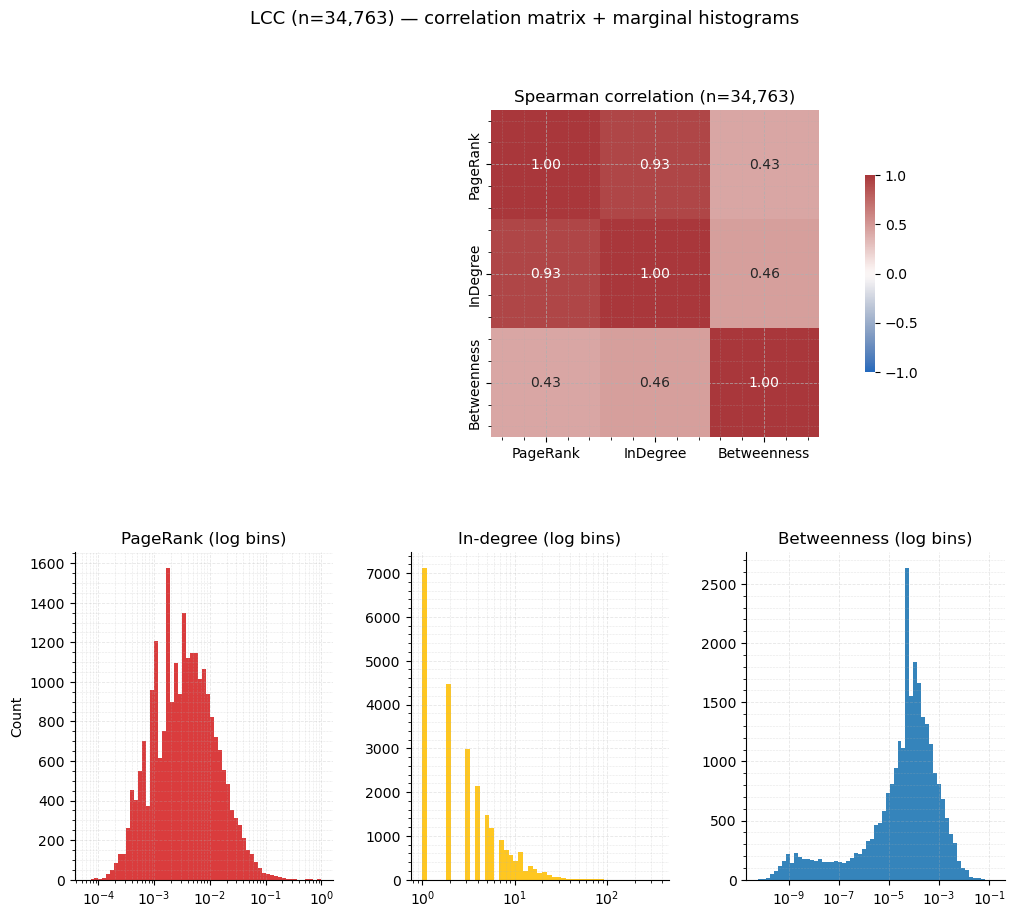

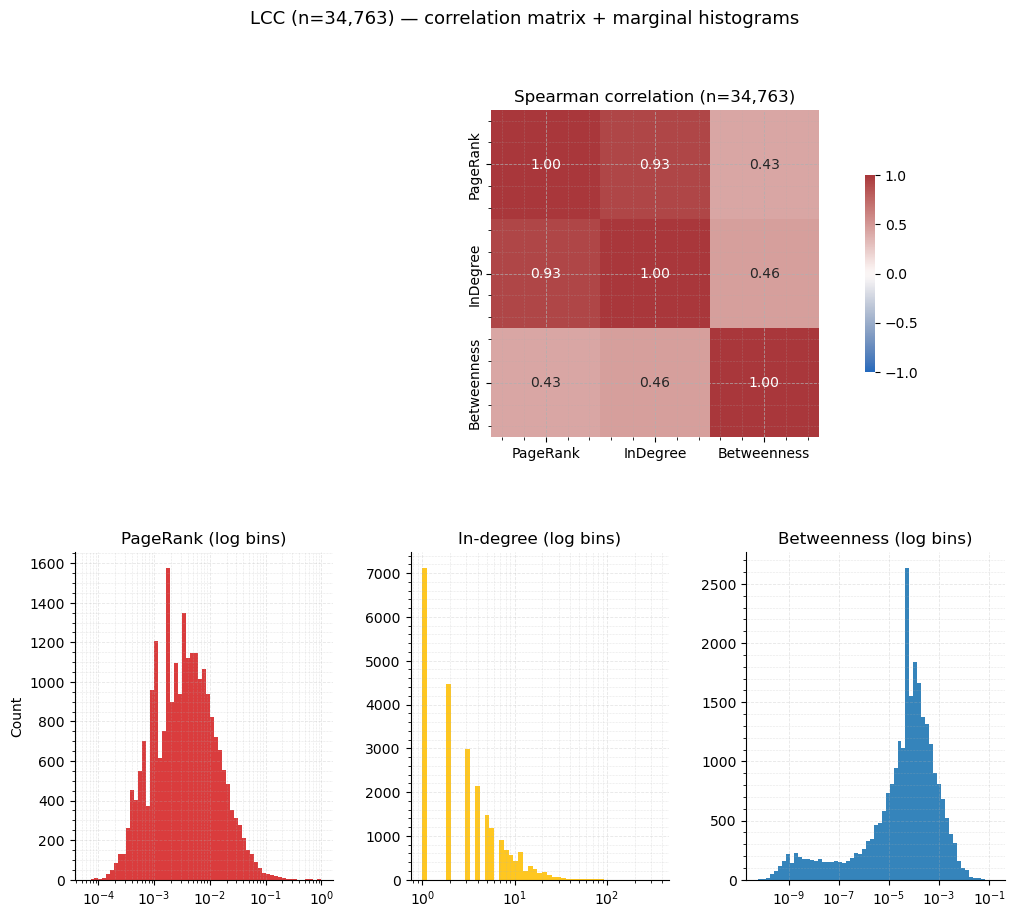

In [49]:
plot_focused_cc_profile(res, out_fig="./focused_cc_profile.png", figsize=(12, 10))

In [83]:
def plot_focused_cc_profile(metrics, out_fig="./focused_cc_profile.png", figsize=(14, 5), corr_methods=None):
    """
    Plot three visualizations in a single row:
    - PageRank histogram (log bins)
    - PR vs Betweenness scatter (log-log)
    - Betweenness histogram (log bins)
    """
    import seaborn as sns
    import pandas as _pd
    import matplotlib as mpl

    if corr_methods is None:
        corr_methods = ["spearman", "kendall"]

    pr_arr = metrics["pr_arr"]
    bw_arr = metrics["bw_arr"].astype(float)
    n_sub = metrics["stats"]["n"]
    sampled = metrics.get("sampled", False)

    # Figure: 1x3 layout
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    ax_hist_pr, ax_sc_pr_bw, ax_hist_bw = axes

    # hist settings
    eps = 1e-12
    pr_col = "#08306B"   # dark blue
    bw_col = "#6BAED6"   # light blue
    scatter_col = "#2171B5"  # medium blue for scatter

    # PageRank histogram (log x if positive values exist)
    pr_pos = pr_arr[pr_arr > 0]
    if pr_pos.size > 0:
        xmin = max(pr_pos.min(), eps)
        xmax = max(pr_arr.max(), xmin * 1.0001)
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num=60)
        ax_hist_pr.hist(pr_pos, bins=bins, color=pr_col, alpha=0.9)
        ax_hist_pr.set_xscale("log")
    else:
        ax_hist_pr.hist(pr_arr + eps, bins=20, color=pr_col, alpha=0.9)
        ax_hist_pr.set_xscale("log")
    ax_hist_pr.set_title("PageRank (log bins)", fontsize=12)
    ax_hist_pr.set_xlabel("PageRank", fontsize=10)
    ax_hist_pr.set_ylabel("Count", fontsize=10)
    tidy_square(ax_hist_pr, make_square=False)
    ax_hist_pr.grid(True, ls="--", alpha=0.3)

    # PR vs Betweenness scatter (middle) - both axes log
    pr_plot = pr_arr.copy()
    pr_plot[pr_plot == 0] = eps
    bw_plot = bw_arr.copy()
    finite_bw_mask = np.isfinite(bw_plot)
    bw_plot[finite_bw_mask & (bw_plot == 0)] = eps

    # set log scales before plotting to ensure axis locators are appropriate
    ax_sc_pr_bw.set_xscale("log")
    ax_sc_pr_bw.set_yscale("log")
    mask = finite_bw_mask & (pr_plot > 0)
    if mask.any():
        ax_sc_pr_bw.scatter(pr_plot[mask], bw_plot[mask], s=16, alpha=0.6, color=scatter_col, edgecolor="none")
    ax_sc_pr_bw.set_xlabel("PageRank (log)", fontsize=10)
    ax_sc_pr_bw.set_ylabel("Betweenness (log)", fontsize=10)
    ax_sc_pr_bw.set_title("PageRank vs Betweenness", fontsize=12)
    tidy_square(ax_sc_pr_bw, make_square=False)
    ax_sc_pr_bw.grid(True, ls="--", alpha=0.35)

    # Betweenness histogram (right)
    finite_bw = bw_arr[np.isfinite(bw_arr) & (bw_arr > 0)]
    if finite_bw.size > 0:
        xmin = max(finite_bw.min(), eps)
        xmax = max(finite_bw.max(), xmin * 1.0001)
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num=60)
        ax_hist_bw.hist(finite_bw, bins=bins, color=bw_col, alpha=0.9)
        ax_hist_bw.set_xscale("log")
    else:
        finite_vals = bw_arr[np.isfinite(bw_arr)]
        if finite_vals.size > 0:
            ax_hist_bw.hist(finite_vals + eps, bins=30, color=bw_col, alpha=0.9)
            ax_hist_bw.set_xscale("log")
        else:
            ax_hist_bw.text(0.5, 0.5, "No betweenness\nvalues", ha="center", va="center", fontsize=10)
    ax_hist_bw.set_title("Betweenness (log bins)", fontsize=12)
    ax_hist_bw.set_xlabel("Betweenness", fontsize=10)
    ax_hist_bw.set_ylabel("Count", fontsize=10)
    tidy_square(ax_hist_bw, make_square=False)
    ax_hist_bw.grid(True, ls="--", alpha=0.3)

    plt.tight_layout()

    try:
        fig.savefig(out_fig, dpi=300)
        fig.savefig(out_fig.replace(".png", ".pdf"))
    except Exception:
        pass

    return fig

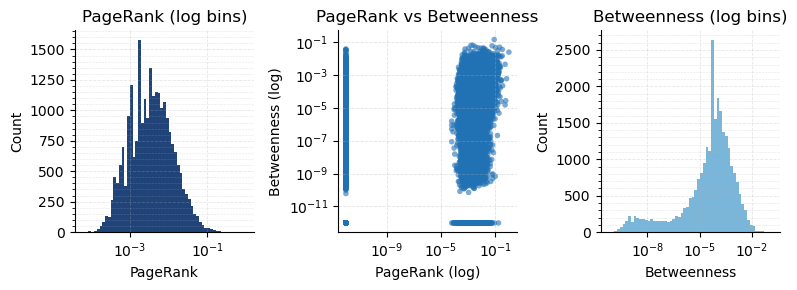

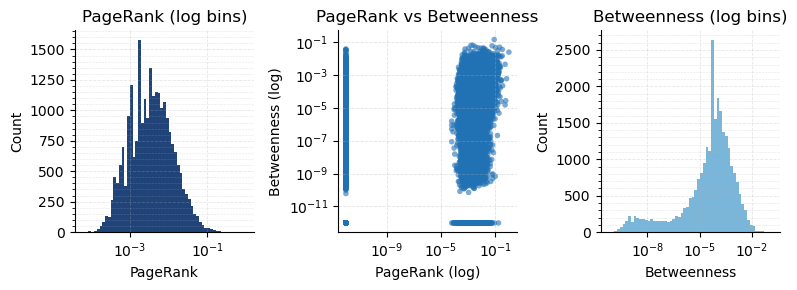

In [87]:
plot_focused_cc_profile(res, out_fig="./focused_cc_profile_corr.png", figsize=(8, 3))

In [91]:
def print_node_categories(metrics):
    """
    Calculate and print node categories based on percentile thresholds for PageRank and Betweenness.
    
    Categories:
    - Global Hubs: >95th percentile in both PR and BW
    - Local Hubs: >95th percentile in PR, <50th percentile in BW
    - Strategic Bridges: <50th percentile in PR, >95th percentile in BW
    - Intermediate Nodes: 50th-95th percentile in both PR and BW
    - Peripheral Nodes: <25th percentile in both PR and BW
    
    Parameters
    ----------
    metrics : dict
        Dictionary containing 'pr_arr' (PageRank array) and 'bw_arr' (Betweenness array)
    
    Returns
    -------
    dict
        Dictionary with category counts and percentages
    """
    import numpy as np
    
    pr_arr = metrics["pr_arr"]
    bw_arr = metrics["bw_arr"].astype(float)
    
    total_nodes = len(pr_arr)
    
    # Calculate percentiles for PageRank
    try:
        pr_p95 = np.nanpercentile(pr_arr, 95)
        pr_p50 = np.nanpercentile(pr_arr, 50)
        pr_p25 = np.nanpercentile(pr_arr, 25)
    except Exception:
        pr_p95, pr_p50, pr_p25 = 1.0, 0.5, 0.25
    
    # Calculate percentiles for Betweenness (only finite values)
    bw_finite = bw_arr[np.isfinite(bw_arr)]
    if bw_finite.size > 0:
        bw_p95 = np.nanpercentile(bw_finite, 95)
        bw_p50 = np.nanpercentile(bw_finite, 50)
        bw_p25 = np.nanpercentile(bw_finite, 25)
    else:
        bw_p95, bw_p50, bw_p25 = np.nan, np.nan, np.nan
    
    # Create masks for categories
    mask_pr_gt95 = pr_arr > pr_p95
    mask_pr_lt50 = pr_arr < pr_p50
    mask_pr_50_95 = (pr_arr >= pr_p50) & (pr_arr <= pr_p95)
    mask_pr_lt25 = pr_arr < pr_p25
    
    mask_bw_gt95 = np.isfinite(bw_arr) & (bw_arr > bw_p95)
    mask_bw_lt50 = np.isfinite(bw_arr) & (bw_arr < bw_p50)
    mask_bw_50_95 = np.isfinite(bw_arr) & (bw_arr >= bw_p50) & (bw_arr <= bw_p95)
    mask_bw_lt25 = np.isfinite(bw_arr) & (bw_arr < bw_p25)
    
    # Count nodes in each category
    cnt_global_hubs = int(np.sum(mask_pr_gt95 & mask_bw_gt95))
    cnt_local_hubs = int(np.sum(mask_pr_gt95 & mask_bw_lt50))
    cnt_bridges = int(np.sum(mask_pr_lt50 & mask_bw_gt95))
    cnt_intermediate = int(np.sum(mask_pr_50_95 & mask_bw_50_95))
    cnt_peripheral = int(np.sum(mask_pr_lt25 & mask_bw_lt25))
    
    # Calculate percentages
    pct_global = 100.0 * cnt_global_hubs / total_nodes
    pct_local = 100.0 * cnt_local_hubs / total_nodes
    pct_bridges = 100.0 * cnt_bridges / total_nodes
    pct_intermediate = 100.0 * cnt_intermediate / total_nodes
    pct_peripheral = 100.0 * cnt_peripheral / total_nodes
    
    # Print results
    print("=" * 80)
    print("NODE CLASSIFICATION BASED ON CENTRALITY METRICS")
    print("=" * 80)
    print(f"Total nodes: {total_nodes:,}")
    print()
    print(f"PageRank percentiles: 25th={pr_p25:.6f}, 50th={pr_p50:.6f}, 95th={pr_p95:.6f}")
    print(f"Betweenness percentiles: 25th={bw_p25:.6f}, 50th={bw_p50:.6f}, 95th={bw_p95:.6f}")
    print()
    print("-" * 80)
    
    # Global Hubs
    print(f"{'GLOBAL HUBS':<25} | N={cnt_global_hubs:>8,} | {pct_global:>6.2f}%")
    print(f"  → PageRank: >95th percentile (>{pr_p95:.6f})")
    print(f"  → Betweenness: >95th percentile (>{bw_p95:.6f})")
    print(f"  → Role: Central and influential nodes")
    print()
    
    # Local Hubs
    print(f"{'LOCAL HUBS':<25} | N={cnt_local_hubs:>8,} | {pct_local:>6.2f}%")
    print(f"  → PageRank: >95th percentile (>{pr_p95:.6f})")
    print(f"  → Betweenness: <50th percentile (<{bw_p50:.6f})")
    print(f"  → Role: Popular but isolated, destinations not intermediaries")
    print()
    
    # Strategic Bridges
    print(f"{'STRATEGIC BRIDGES':<25} | N={cnt_bridges:>8,} | {pct_bridges:>6.2f}%")
    print(f"  → PageRank: <50th percentile (<{pr_p50:.6f})")
    print(f"  → Betweenness: >95th percentile (>{bw_p95:.6f})")
    print(f"  → Role: Community connectors, critical for network cohesion")
    print()
    
    # Intermediate Nodes
    print(f"{'INTERMEDIATE NODES':<25} | N={cnt_intermediate:>8,} | {pct_intermediate:>6.2f}%")
    print(f"  → PageRank: 50th-95th percentile ({pr_p50:.6f} - {pr_p95:.6f})")
    print(f"  → Betweenness: 50th-95th percentile ({bw_p50:.6f} - {bw_p95:.6f})")
    print(f"  → Role: Moderate role in the network")
    print()
    
    # Peripheral Nodes
    print(f"{'PERIPHERAL NODES':<25} | N={cnt_peripheral:>8,} | {pct_peripheral:>6.2f}%")
    print(f"  → PageRank: <25th percentile (<{pr_p25:.6f})")
    print(f"  → Betweenness: <25th percentile (<{bw_p25:.6f})")
    print(f"  → Role: Marginal in network, low integration")
    print()
    
    print("-" * 80)
    
    # Summary check
    total_categorized = cnt_global_hubs + cnt_local_hubs + cnt_bridges + cnt_intermediate + cnt_peripheral
    pct_categorized = 100.0 * total_categorized / total_nodes
    print(f"{'Nodes categorized':<25} | N={total_categorized:>8,} | {pct_categorized:>6.2f}%")
    print(f"{'Nodes uncategorized':<25} | N={total_nodes - total_categorized:>8,} | {100.0 - pct_categorized:>6.2f}%")
    print("=" * 80)
    
    # Return dictionary with results
    results = {
        "total_nodes": total_nodes,
        "percentiles": {
            "pr": {"p25": pr_p25, "p50": pr_p50, "p95": pr_p95},
            "bw": {"p25": bw_p25, "p50": bw_p50, "p95": bw_p95}
        },
        "categories": {
            "global_hubs": {"count": cnt_global_hubs, "percentage": pct_global},
            "local_hubs": {"count": cnt_local_hubs, "percentage": pct_local},
            "strategic_bridges": {"count": cnt_bridges, "percentage": pct_bridges},
            "intermediate_nodes": {"count": cnt_intermediate, "percentage": pct_intermediate},
            "peripheral_nodes": {"count": cnt_peripheral, "percentage": pct_peripheral}
        },
        "masks": {
            "global_hubs": mask_pr_gt95 & mask_bw_gt95,
            "local_hubs": mask_pr_gt95 & mask_bw_lt50,
            "strategic_bridges": mask_pr_lt50 & mask_bw_gt95,
            "intermediate_nodes": mask_pr_50_95 & mask_bw_50_95,
            "peripheral_nodes": mask_pr_lt25 & mask_bw_lt25
        }
    }
    
    return results

In [93]:
category_stats = print_node_categories(res)

# Accedi ai risultati
print(f"\nGlobal hubs: {category_stats['categories']['global_hubs']['count']}")
print(f"PageRank 95th percentile: {category_stats['percentiles']['pr']['p95']:.6f}")

# Ottieni le maschere per filtrare i nodi
global_hub_mask = category_stats['masks']['global_hubs']
global_hub_indices = np.where(global_hub_mask)[0]

NODE CLASSIFICATION BASED ON CENTRALITY METRICS
Total nodes: 34,763

PageRank percentiles: 25th=0.000000, 50th=0.001606, 95th=0.022636
Betweenness percentiles: 25th=0.000000, 50th=0.000026, 95th=0.001637

--------------------------------------------------------------------------------
GLOBAL HUBS               | N=     317 |   0.91%
  → PageRank: >95th percentile (>0.022636)
  → Betweenness: >95th percentile (>0.001637)
  → Role: Central and influential nodes

LOCAL HUBS                | N=     247 |   0.71%
  → PageRank: >95th percentile (>0.022636)
  → Betweenness: <50th percentile (<0.000026)
  → Role: Popular but isolated, destinations not intermediaries

STRATEGIC BRIDGES         | N=     433 |   1.25%
  → PageRank: <50th percentile (<0.001606)
  → Betweenness: >95th percentile (>0.001637)
  → Role: Community connectors, critical for network cohesion

INTERMEDIATE NODES        | N=   9,087 |  26.14%
  → PageRank: 50th-95th percentile (0.001606 - 0.022636)
  → Betweenness: 50th-95t